In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from break_detection import cusum_detect, run_cusum_on_candidates, validate_against_christmas

In [2]:
categories = ['foods', 'hobbies', 'household']
category_data = {}

for cat in categories:
    long_df = pd.read_csv(f"../data/interim/{cat}_candidates.csv", parse_dates=['date'])
    category_data[cat] = long_df
    print(f"{cat}: {long_df['item_id'].nunique()} items, {len(long_df)} rows")

foods: 337 items, 609203 rows
hobbies: 106 items, 193523 rows
household: 283 items, 487284 rows


In [3]:
all_break_results = {}

for cat, long_df in category_data.items():
    print(f"\n=== Running CUSUM on {cat.upper()} ===")
    candidates = long_df['item_id'].unique().tolist()
    break_df = run_cusum_on_candidates(long_df, candidates)

    n_breaks = break_df['break_detected'].sum()
    pct_breaks = n_breaks / len(break_df) * 100
    print(f"{n_breaks} of {len(break_df)} items ({pct_breaks:.1f}%) flagged with a structural break")

    break_df.to_csv(f"../data/interim/{cat}_break_detection.csv", index=False)
    all_break_results[cat] = break_df

break_summary = pd.DataFrame({
    cat: {'total_items': len(df), 'breaks_detected': df['break_detected'].sum(),
          'pct_with_break': round(df['break_detected'].mean()*100, 1)}
    for cat, df in all_break_results.items()
}).T
print("\n=== Break Detection Summary ===")
print(break_summary)


=== Running CUSUM on FOODS ===
337 of 337 items (100.0%) flagged with a structural break

=== Running CUSUM on HOBBIES ===
106 of 106 items (100.0%) flagged with a structural break

=== Running CUSUM on HOUSEHOLD ===
283 of 283 items (100.0%) flagged with a structural break

=== Break Detection Summary ===
           total_items  breaks_detected  pct_with_break
foods            337.0            337.0           100.0
hobbies          106.0            106.0           100.0
household        283.0            283.0           100.0


In [4]:
for cat, long_df in category_data.items():
    christmas_check = validate_against_christmas(all_break_results[cat], long_df)
    pct_zero_christmas = christmas_check['is_zero'].mean() * 100
    print(f"{cat}: Christmas Day was zero-sales in {pct_zero_christmas:.1f}% of item-years checked")

foods: Christmas Day was zero-sales in 98.7% of item-years checked
hobbies: Christmas Day was zero-sales in 100.0% of item-years checked
household: Christmas Day was zero-sales in 100.0% of item-years checked


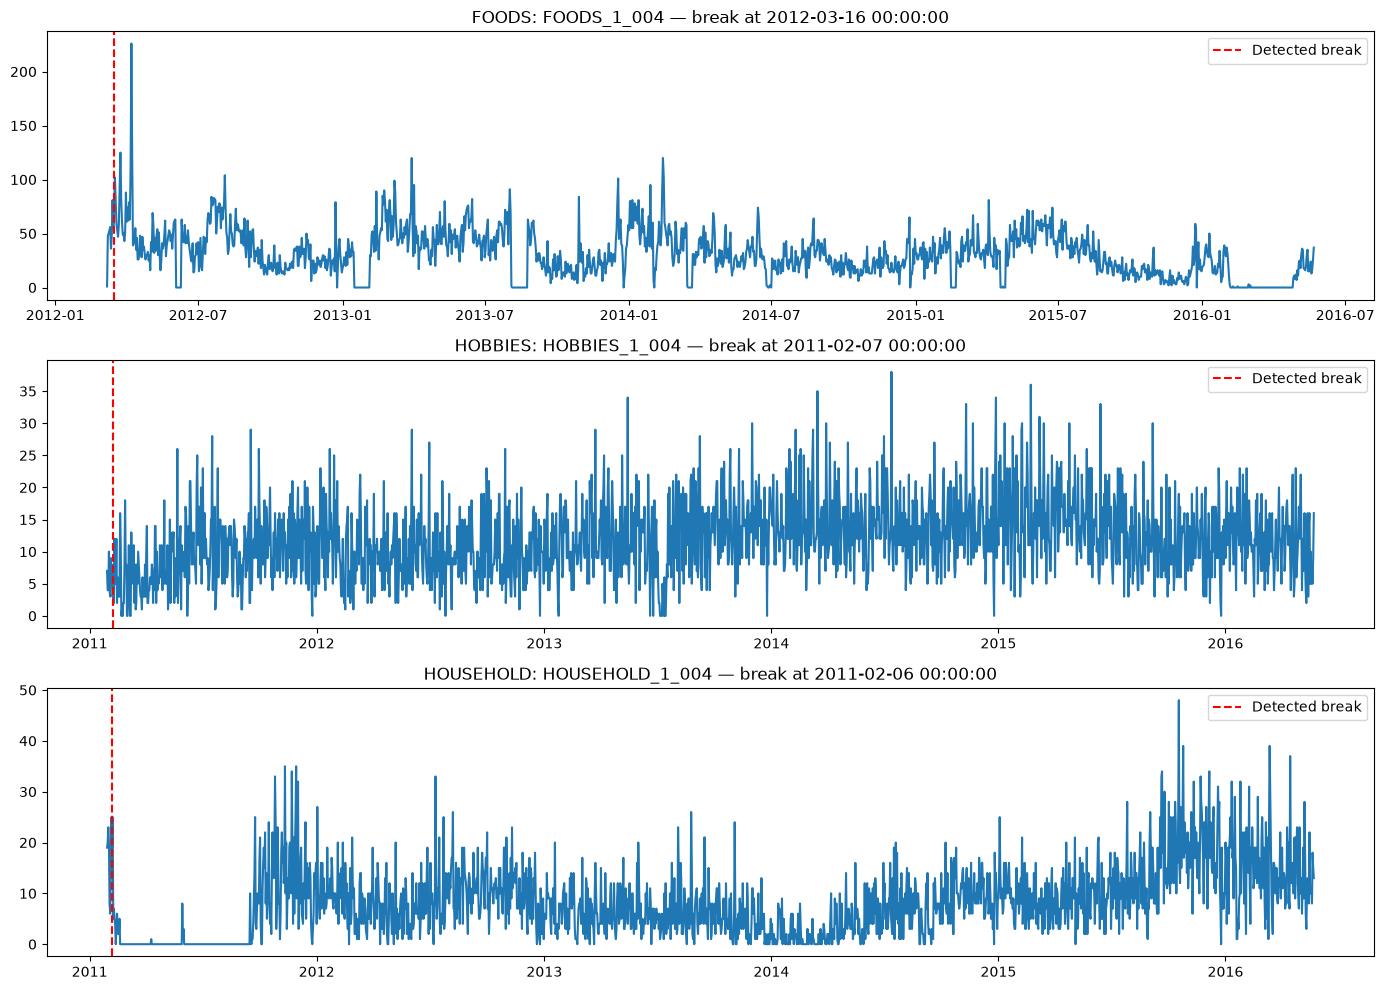

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, (cat, long_df) in zip(axes, category_data.items()):
    break_df = all_break_results[cat]
    flagged = break_df[break_df['break_detected']]
    if len(flagged) == 0:
        continue
    sample_item = flagged.iloc[0]['item_id']
    break_date = flagged.iloc[0]['break_date']

    series = long_df[long_df['item_id'] == sample_item].sort_values('date')
    ax.plot(series['date'], series['sales'])
    ax.axvline(pd.to_datetime(break_date), color='red', linestyle='--', label='Detected break')
    ax.set_title(f"{cat.upper()}: {sample_item} — break at {break_date}")
    ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/sample_breaks_per_category.png")
plt.show()